Epoch 0, Loss: 0.2585
Epoch 100, Loss: 0.1034
Epoch 200, Loss: 0.0974
Epoch 300, Loss: 0.0937
Epoch 400, Loss: 0.0906
Epoch 500, Loss: 0.0876
Epoch 600, Loss: 0.0841
Epoch 700, Loss: 0.0798
Epoch 800, Loss: 0.0744
Epoch 900, Loss: 0.0677


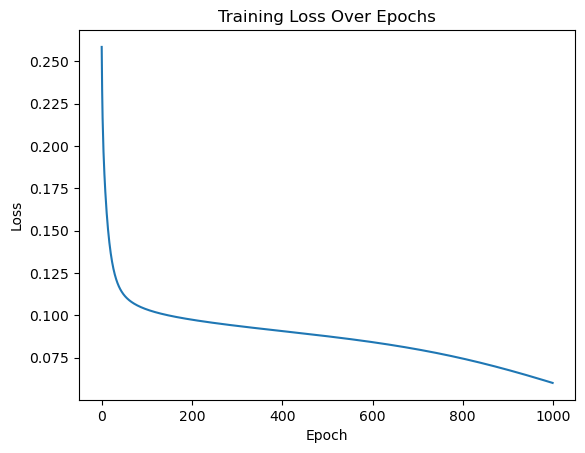

Test Accuracy: 96.67%


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

class NeuralNetwork:
    def __init__(self, layer_sizes, activation='sigmoid', learning_rate=0.01):
        """
        Initialize the neural network.
        
        Parameters:
        - layer_sizes: list of integers representing the number of neurons in each layer
        - activation: activation function to use ('sigmoid' or 'relu')
        - learning_rate: learning rate for gradient descent
        """
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.learning_rate = learning_rate
        self.weights = []
        self.biases = []
        self.loss_history = []
        
        # Initialize weights and biases
        for i in range(len(layer_sizes) - 1):
            # He initialization for ReLU, Xavier for sigmoid
            if activation == 'relu':
                std = np.sqrt(2. / layer_sizes[i])
            else:
                std = np.sqrt(1. / layer_sizes[i])
            
            self.weights.append(np.random.randn(layer_sizes[i], layer_sizes[i+1]) * std)
            self.biases.append(np.zeros((1, layer_sizes[i+1])))
    
    def sigmoid(self, x):
        """Sigmoid activation function."""
        return 1 / (1 + np.exp(-x))
    
    def relu(self, x):
        """ReLU activation function."""
        return np.maximum(0, x)
    
    def sigmoid_derivative(self, x):
        """Derivative of sigmoid activation function."""
        return x * (1 - x)
    
    def relu_derivative(self, x):
        """Derivative of ReLU activation function."""
        return (x > 0).astype(float)
    
    def forward(self, X):
        """Forward propagation through the network."""
        self.activations = [X]
        self.z_values = []
        
        for i in range(len(self.weights)):
            z = np.dot(self.activations[-1], self.weights[i]) + self.biases[i]
            self.z_values.append(z)
            
            if i == len(self.weights) - 1:
                # Output layer (no activation for regression, softmax for classification)
                a = z
            else:
                # Hidden layers
                if self.activation == 'sigmoid':
                    a = self.sigmoid(z)
                else:
                    a = self.relu(z)
            
            self.activations.append(a)
        
        return self.activations[-1]
    
    def compute_loss(self, y_true, y_pred):
        """Compute mean squared error loss."""
        return np.mean((y_true - y_pred) ** 2)
    
    def backward(self, X, y):
        """Backpropagation to compute gradients."""
        m = X.shape[0]
        gradients_w = [np.zeros(w.shape) for w in self.weights]
        gradients_b = [np.zeros(b.shape) for b in self.biases]
        
        # Output layer gradient
        error = self.activations[-1] - y
        delta = error
        
        gradients_w[-1] = np.dot(self.activations[-2].T, delta) / m
        gradients_b[-1] = np.sum(delta, axis=0, keepdims=True) / m
        
        # Hidden layers gradients
        for l in range(len(self.weights) - 2, -1, -1):
            if self.activation == 'sigmoid':
                delta = np.dot(delta, self.weights[l+1].T) * self.sigmoid_derivative(self.activations[l+1])
            else:
                delta = np.dot(delta, self.weights[l+1].T) * self.relu_derivative(self.activations[l+1])
            
            gradients_w[l] = np.dot(self.activations[l].T, delta) / m
            gradients_b[l] = np.sum(delta, axis=0, keepdims=True) / m
        
        return gradients_w, gradients_b
    
    def update_parameters(self, gradients_w, gradients_b):
        """Update weights and biases using gradient descent."""
        for i in range(len(self.weights)):
            self.weights[i] -= self.learning_rate * gradients_w[i]
            self.biases[i] -= self.learning_rate * gradients_b[i]
    
    def train(self, X, y, epochs=1000, verbose=100):
        """Train the neural network."""
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Backward pass
            gradients_w, gradients_b = self.backward(X, y)
            
            # Update parameters
            self.update_parameters(gradients_w, gradients_b)
            
            if verbose and epoch % verbose == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    
    def predict(self, X):
        """Make predictions using the trained network."""
        return self.forward(X)
    
    def plot_loss(self):
        """Plot training loss over epochs."""
        plt.plot(self.loss_history)
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Loss Over Epochs')
        plt.show()

# Example usage with Iris dataset
def prepare_iris_data():
    # Load and prepare Iris dataset
    iris = load_iris()
    X = iris.data
    y = iris.target.reshape(-1, 1)
    
    # Standardize features
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    # One-hot encode labels
    encoder = OneHotEncoder()
    y = encoder.fit_transform(y).toarray()
    
    return train_test_split(X, y, test_size=0.2, random_state=42)

def main():
    # Prepare data
    X_train, X_test, y_train, y_test = prepare_iris_data()
    
    # Create and train network
    nn = NeuralNetwork(layer_sizes=[4, 8, 3], activation='sigmoid', learning_rate=0.1)
    nn.train(X_train, y_train, epochs=1000, verbose=100)
    
    # Plot training loss
    nn.plot_loss()
    
    # Evaluate on test set
    predictions = nn.predict(X_test)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(y_test, axis=1)
    accuracy = np.mean(predicted_classes == true_classes)
    print(f"Test Accuracy: {accuracy * 100:.2f}%")

if __name__ == "__main__":
    main()